In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import folium
from folium.plugins import HeatMap
sf_df = pd.read_csv("df_assignment.csv")
sf_df = sf_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)

sf_df = sf_df[sf_df['police_district'] != 'out of sf']
sf_df = sf_df[sf_df["category"] != "non-criminal"]
sf_df = sf_df[sf_df["category"] != "other offenses"]

C:\Users\Jacob pc\AppData\Local\Temp\ipykernel_27348\3544617024.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sf_df = sf_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [2]:
sf_df["category"] = sf_df["category"].str.lower().str.strip()
category_map = {
    # Drug-related
    "drug offense": "drug offense",
    "drug violation": "drug offense",

    # Prostitution-related
    "prostitution": "prostitution",
    "human trafficking (a), commercial sex acts": "prostitution",
    "human trafficking, commercial sex acts": "prostitution",

    # Vandalism-related
    "vandalism": "vandalism",
    "malicious mischief": "vandalism",

    # Optional: robbery
    "robbery": "robbery",
}


sf_df["category"] = sf_df["category"].replace(category_map)



In [4]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMapWithTime

df = sf_df.copy()
df["category"] = df["category"].astype(str).str.lower().str.strip()
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

drug_df = df[
    (df["category"] == "drug offense") &
    df["datetime"].notna() &
    df["latitude"].notna() &
    df["longitude"].notna()
].copy()

drug_df["year"] = drug_df["datetime"].dt.year.astype(int)
drug_df = drug_df[(drug_df["year"] >= 2003) & (drug_df["year"] <= 2025)].copy()

# Small spatial bins
grid_size = 0.003

drug_df["lat_bin"] = np.floor(drug_df["latitude"] / grid_size) * grid_size
drug_df["lon_bin"] = np.floor(drug_df["longitude"] / grid_size) * grid_size

# Count incidents per bin per year
binned = (
    drug_df.groupby(["year", "lat_bin", "lon_bin"])
    .size()
    .reset_index(name="count")
)

years = sorted(binned["year"].unique())

heat_data = []
for y in years:
    tmp = binned[binned["year"] == y].copy()

    # Optional: remove tiny cells entirely
    tmp = tmp[tmp["count"] >= 2].copy()

    if len(tmp) == 0:
        heat_data.append([])
        continue

    # Log-scale weights and normalize within year to [0, 1]
    tmp["weight"] = np.log1p(tmp["count"])
    tmp["weight"] = tmp["weight"] / tmp["weight"].max()

    # Center points inside each bin
    tmp["lat_center"] = tmp["lat_bin"] + grid_size / 2
    tmp["lon_center"] = tmp["lon_bin"] + grid_size / 2

    heat_data.append(
        tmp[["lat_center", "lon_center", "weight"]].values.tolist()
    )

m = folium.Map(location=[37.77, -122.42], zoom_start=12)

HeatMapWithTime(
    heat_data,
    index=[str(y) for y in years],
    radius=16,
    min_opacity=0.03,
    max_opacity=0.75,
    auto_play=False
).add_to(m)

m
m.save("drug_heatmap_yearly_weighted.html")

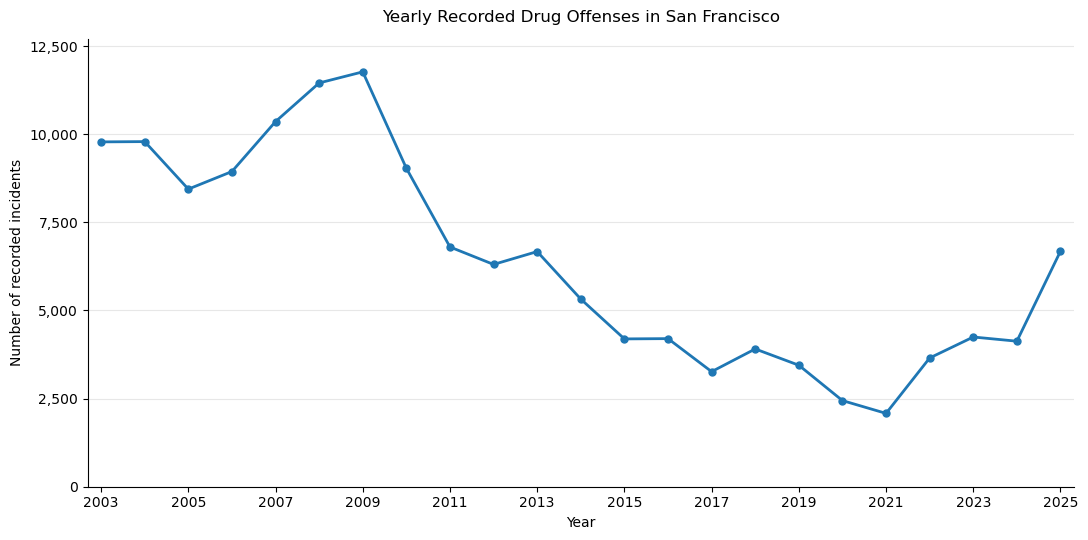

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter

yearly_drug = (
    drug_df.groupby("year")
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    yearly_drug["year"],
    yearly_drug["count"],
    marker="o",
    linewidth=2,
    markersize=5
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of recorded incidents")

# Meaningful axis ticks
ax.set_xticks(yearly_drug["year"][::2])  # every second year
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Avoid cramped axes
ax.set_xlim(yearly_drug["year"].min() - 0.3, yearly_drug["year"].max() + 0.3)
ax.set_ylim(0, yearly_drug["count"].max() * 1.08)

# Clean grid
ax.grid(axis="y", alpha=0.3)

# Remove unnecessary top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("drug_offenses_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import plotly.graph_objects as go

# Reuse the binned data you already created:
# binned = drug_df.groupby(["year", "lat_bin", "lon_bin"]).size().reset_index(name="count")

# Total drug offenses per year
total_year = (
    binned.groupby("year")["count"]
    .sum()
    .reset_index(name="total_count")
)

# Function to compute share captured by top n cells each year
def top_n_share(df, n):
    top_n = (
        df.sort_values(["year", "count"], ascending=[True, False])
        .groupby("year")
        .head(n)
        .groupby("year")["count"]
        .sum()
        .reset_index(name="top_count")
    )
    out = total_year.merge(top_n, on="year", how="left")
    out["share"] = out["top_count"] / out["total_count"]
    out["k"] = n
    return out[["year", "share", "k"]]

# Choose which k values the user can switch between
k_values = [1, 3, 5, 10, 20, 50]

# Build one dataframe with all k values
topk_df = pd.concat([top_n_share(binned, k) for k in k_values], ignore_index=True)

# Build interactive figure
fig = go.Figure()

for i, k in enumerate(k_values):
    df_k = topk_df[topk_df["k"] == k]
    fig.add_trace(
        go.Scatter(
            x=df_k["year"],
            y=df_k["share"],
            mode="lines+markers",
            name=f"Top {k} cells",
            visible=(i == 0),  # show only first one initially
            hovertemplate=(
                "Year: %{x}<br>"
                f"Top {k} cells share: "
                "%{y:.1%}<extra></extra>"
            )
        )
    )

# Dropdown menu
buttons = []
for i, k in enumerate(k_values):
    visible = [False] * len(k_values)
    visible[i] = True
    
    buttons.append(
        dict(
            label=f"Top {k}",
            method="update",
            args=[
                {"visible": visible},
                {
                    "title": f"Share of Drug Offenses in the Top {k} Grid Cells",
                    "yaxis": {"title": "Share of all drug offenses"}
                }
            ]
        )
    )

fig.update_layout(
    title=f"Share of Drug Offenses in the Top {k_values[0]} Grid Cells",
    xaxis_title="Year",
    yaxis_title="Share of all drug offenses",
    template="plotly_white",
    title_x=0.5,
    yaxis_tickformat=".0%",
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.02,
            xanchor="left",
            y=1,
            yanchor="top"
        )
    ],
    margin=dict(l=60, r=170, t=70, b=60)
)

fig.show()
fig.write_html("drug_concentration_topk_interactive.html")

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Total drug offenses per year
total_year = (
    binned.groupby("year")["count"]
    .sum()
    .reset_index(name="total_count")
)

def top_n_share(df, n):
    top_n = (
        df.sort_values(["year", "count"], ascending=[True, False])
        .groupby("year")
        .head(n)
        .groupby("year")["count"]
        .sum()
        .reset_index(name="top_count")
    )
    out = total_year.merge(top_n, on="year", how="left")
    out["share"] = out["top_count"] / out["total_count"]
    out["k"] = n

    baseline = out["share"].iloc[0]
    out["index"] = 100 * out["share"] / baseline if baseline > 0 else 100

    return out[["year", "share", "index", "k"]]

max_k = 50

topk_df = pd.concat(
    [top_n_share(binned, k) for k in range(1, max_k + 1)],
    ignore_index=True
)

fig = go.Figure()

# Share traces
for k in range(1, max_k + 1):
    df_k = topk_df[topk_df["k"] == k]
    fig.add_trace(
        go.Scatter(
            x=df_k["year"],
            y=df_k["share"],
            mode="lines",
            line=dict(width=3),
            name=f"Share k={k}",
            visible=(k == 1),
            hovertemplate=(
                "Year: %{x}<br>"
                + f"Top {k} cells share: "
                + "%{y:.1%}<extra></extra>"
            )
        )
    )

# Index traces
for k in range(1, max_k + 1):
    df_k = topk_df[topk_df["k"] == k]
    fig.add_trace(
        go.Scatter(
            x=df_k["year"],
            y=df_k["index"],
            mode="lines",
            line=dict(width=3),
            name=f"Index k={k}",
            visible=False,
            hovertemplate=(
                "Year: %{x}<br>"
                + f"Top {k} cells index: "
                + "%{y:.0f}<extra></extra>"
            )
        )
    )

# Slider defaults to share traces
steps = []
for k in range(1, max_k + 1):
    visible = [False] * (2 * max_k)
    visible[k - 1] = True

    steps.append(
        dict(
            method="update",
            args=[
                {"visible": visible},
                {
                    "title": f"Share of Drug Offenses in Top {k} Grid Cells",
                    "yaxis": {
                        "title": "Share of all drug offenses",
                        "tickformat": ".0%",
                        "range": [0, 1]
                    }
                }
            ],
            label=str(k)
        )
    )

fig.update_layout(
    title="Share of Drug Offenses in Top 1 Grid Cells",
    xaxis_title="Year",
    yaxis=dict(
        title="Share of all drug offenses",
        tickformat=".0%",
        range=[0, 1]
    ),
    template="plotly_white",
    title_x=0.5,
    sliders=[dict(
        active=0,
        currentvalue={"prefix": "k = "},
        pad={"t": 40},
        steps=steps
    )],
    margin=dict(l=60, r=60, t=80, b=80)
)

fig.show()
fig.write_html("drug_concentration_topk_slide.html")